Imports and config (always run this first)

In [1]:
import os
import numpy as np
import sys
sys.path.append('/mnt/md0/tempFolder/samAnderson/unet-gnn/') 
sys.path.append('/mnt/md0/tempFolder/samAnderson/unet-gnn/functions/') 
from config import sex_config as cfg
from postprocessing import PostProcessor
%load_ext autoreload
%autoreload 2

p = PostProcessor(cfg.first)

Determine if sex cohorts are significantly different in age

In [ ]:
# Q: why not do this across cohorts? 
# A: Bias-correction accounts for this. But since it's fit on test_CN, it won't deal with sex-specific CA biases in test_CN

from scipy.stats import ttest_ind

# Load in the CA data for the CNs
y_test_CN = np.load(cfg.y_test_CN)

# Split by sex
sex_labels = np.load(cfg.sex_labels)
female = y_test_CN[sex_labels == 'Female']
male = y_test_CN[sex_labels == 'Male']

# Run t-test and get p-value to determine distributional differences
t_stat, p_val = ttest_ind(female, male, equal_var=False)
print(f"Female vs Male: t={t_stat:.3f}, p={p_val:.5f}")

Female vs Male: t=-5.401, p=0.00000


Drop males and females to account for these differences, and compute GBAGs and LBAG differences

In [ ]:
from scipy.stats import ttest_ind

# Load data
bc_gbags = np.load(cfg.bc_gbags)
bc_lbags = np.load(cfg.bc_lbags)
y_test_CN = np.load(cfg.y_test_CN)
sex_labels = np.load(cfg.sex_labels)

# Create 1-year age bins
rng = np.random.default_rng(0)
age_min = int(np.floor(y_test_CN.min()))
age_max = int(np.ceil(y_test_CN.max()))
bins = np.arange(age_min, age_max + 1)
digitized = np.digitize(y_test_CN, bins)

# Subsample to match distributions (No replacement)
matched_f_idx = []
matched_m_idx = []

for b in np.unique(digitized):

    mask_bin = digitized == b

    f_idx = np.where((sex_labels == 'Female') & mask_bin)[0]
    m_idx = np.where((sex_labels == 'Male') & mask_bin)[0]

    if len(f_idx) == 0 or len(m_idx) == 0:
        continue

    n = min(len(f_idx), len(m_idx))

    # subsample WITHOUT replacement (not bootstrap)
    f_sel = rng.choice(f_idx, size=n, replace=False)
    m_sel = rng.choice(m_idx, size=n, replace=False)

    matched_f_idx.append(f_sel)
    matched_m_idx.append(m_sel)

# Compute matched indices
matched_f_idx = np.concatenate(matched_f_idx)
matched_m_idx = np.concatenate(matched_m_idx)

# Compute gbags
matched_gbag_f = bc_gbags[matched_f_idx]
matched_gbag_m = bc_gbags[matched_m_idx]

# Compute lbags (averaged across subjs)
matched_lbag_f = bc_lbags[matched_f_idx].mean(axis=0)
matched_lbag_m = bc_lbags[matched_m_idx].mean(axis=0)

# Compute lbag difference map
lbag_diff = matched_lbag_f - matched_lbag_m

# Sanity checks
t_stat, p_val = ttest_ind(matched_gbag_m, matched_gbag_f, equal_var=False)
print("Matched subjects per group:", len(matched_gbag_f))
print("Original subjects:", len(bc_gbags))

print("Mean age (F):", y_test_CN[matched_f_idx].mean())
print("Mean age (M):", y_test_CN[matched_m_idx].mean())

print("Global gap test: t =", round(t_stat, 3), "p =", round(p_val, 5))

# Save arrays
os.makedirs(cfg.array_path, exist_ok=True)
np.save(f'{cfg.array_path}f-subsample_gbags.npy', matched_gbag_f)
np.save(f'{cfg.array_path}m-subsample_gbags.npy', matched_gbag_m)
np.save(f'{cfg.array_path}f-m_lbag_diff.npy', lbag_diff)
np.save(f'{cfg.array_path}f-subsample_lbags.npy', matched_lbag_f)
np.save(f'{cfg.array_path}m-subsample_lbags.npy', matched_lbag_m)

Matched subjects per group: 467
Original subjects: 1128
Mean age (F): 75.84304068522484
Mean age (M): 75.81927194860813
Global gap test: t = 4.089 p = 5e-05


Visualize GBAG differences across sexes

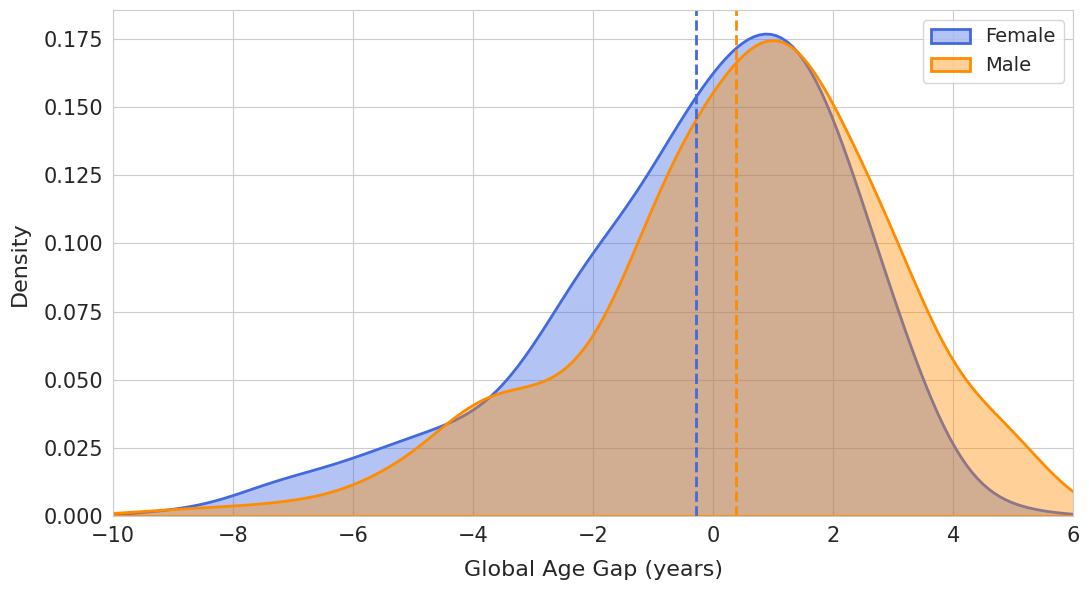

In [ ]:
from IPython.display import Image, display

sex_labels = np.load(cfg.sex_labels)
cohorts = {
    'Female' : np.load(f'{cfg.array_path}f-subsample_gbags.npy'),
    'Male' : np.load(f'{cfg.array_path}m-subsample_gbags.npy')
}

os.makedirs(cfg.vis_path, exist_ok=True)
save_path = f'{cfg.vis_path}f-m_gbags.png'
cfg.gbag_kde(cohorts, save_to=save_path, return_plot=True)

In [3]:
f_gbags = np.load(f'{cfg.array_path}f-subsample_gbags.npy')
m_gbags = np.load(f'{cfg.array_path}m-subsample_gbags.npy')
avg_diff = np.mean(f_gbags) - np.mean(m_gbags)
del f_gbags, m_gbags
avg_diff

np.float64(-0.6710508989700948)

Visualize differences in cohort LBAGs

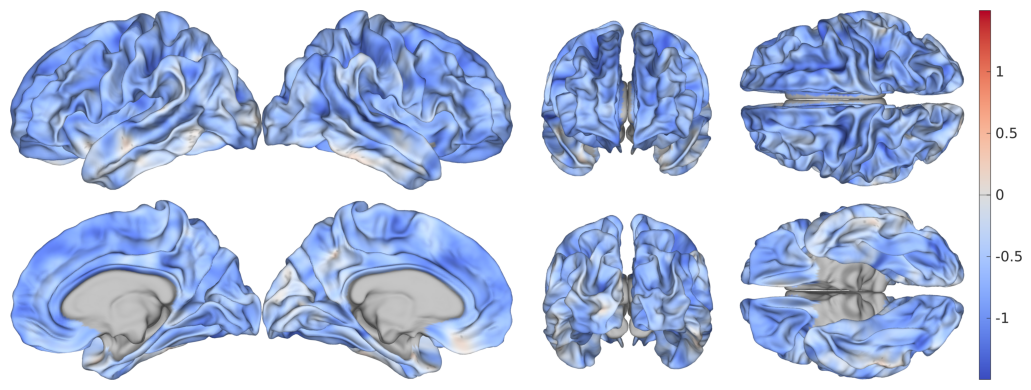

In [2]:
# Make appropriate visualization folder
os.makedirs(cfg.vis_path, exist_ok=True)

# Generate cortical plot
lbag_plot_path = f'{cfg.vis_path}f-m_lbag_diff'
p.generate_cortical_plot(
    np.load(f'{cfg.array_path}f-m_lbag_diff.npy'),
    medial_present = False,
    save_to = lbag_plot_path
)

# Display these
cfg.plot_brain_pairs(
    plot_paths = [
        f'{lbag_plot_path}_latL_latR_medR_medL.png',
        f'{lbag_plot_path}_ant_dor_pos_ven.png'
    ],
    subplot_labels = ['', '']
)

Get network and region-level LBAGs and LBAG differences across sexes

In [4]:
# Load LBAGs
lbags = {'F (CN)' : np.load(f'{cfg.array_path}f-subsample_lbags.npy'), 
         'M (CN)' : np.load(f'{cfg.array_path}m-subsample_lbags.npy')
         }

# Define differences
diff_pairs = {
    'F-M (CN)': ('F (CN)', 'M (CN)')
}

# Build tables
df_region = cfg.build_location_df(
    lbags, p,
    per='region',
    medial_present=False,
    add_diffs=True,
    diff_pairs=diff_pairs
)

df_network = cfg.build_location_df(
    lbags, p,
    per='network',
    medial_present=False,
    add_diffs=True,
    diff_pairs=diff_pairs
)

# Build region to lobe mapping
region_to_lobe = {
    region: lobe
    for lobe, regions in cfg.region_to_lobe_dict.items()
    for region in regions
}

# Map regions to lobes
df_lobe = df_region.copy()
df_lobe['lobe'] = df_lobe['region'].map(region_to_lobe)
df_lobe = df_lobe.dropna(subset=['lobe'])
df_lobe = df_lobe.groupby('lobe').mean(numeric_only=True).reset_index()

# Ensure output directory exists
out_dir = f'{cfg.postprocessed_data_path}ADNI_CN/sex/arrays/'
os.makedirs(out_dir, exist_ok=True)

# Save dfs
df_region.to_csv(f'{out_dir}sex_region_LBAGs.csv')
df_lobe.to_csv(f'{out_dir}sex_lobe_LBAGs.csv')
df_network.to_csv(f'{out_dir}sex_network_LBAGs.csv')